In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
path_file = "../data/googleplaystore.csv"
df = pd.read_csv(path_file)
print("Raw shape:", df.shape)

Raw shape: (10841, 13)


In [2]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
df = df[df['Category'] != '1.9'].copy()
print("Shape after dropping malformed row:", df.shape)

Shape after dropping malformed row: (10840, 13)


In [4]:
df['Installs'] = df['Installs'].astype(str).str.replace(r'[+,]', '', regex=True)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce').astype('Int64')

df['Price'] = df['Price'].astype(str).str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce').astype('Int64')

def clean_size(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x == 'Varies with device':
        return np.nan
    try:
        if x.endswith('M'):
            return float(x[:-1])
        if x.endswith(('k', 'K')):
            return float(x[:-1]) / 1000.0
        return float(x)
    except ValueError:
        return np.nan

df['Size'] = df['Size'].apply(clean_size)  # MB

df['Type'] = df['Type'].replace('0', 'Free')
df['Type'] = df['Type'].fillna(df.apply(lambda r: 'Paid' if r['Price'] > 0 else 'Free', axis=1))

df[['Installs', 'Price', 'Reviews', 'Size']].dtypes


Installs      Int64
Price       float64
Reviews       Int64
Size        float64
dtype: object

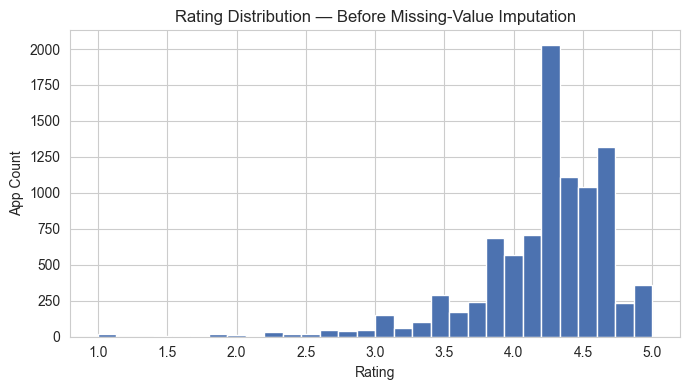

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
df['Rating'].dropna().hist(bins=30, ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Rating Distribution — Before Missing-Value Imputation')
ax.set_xlabel('Rating')
ax.set_ylabel('App Count')
plt.tight_layout()
plt.savefig('rating_hist_before.png')
plt.show()

In [6]:
dupe_count = df['App'].duplicated().sum()
print("Duplicate App rows found:", dupe_count)
df = df.sort_values('Reviews', ascending=False).drop_duplicates(subset='App', keep='first')
print("Shape after deduplication:", df.shape)

Duplicate App rows found: 1181
Shape after deduplication: (9659, 13)


In [7]:
rating_na = df['Rating'].isna().sum()
size_na = df['Size'].isna().sum()
print(f"Rating NaNs before fill: {rating_na}")
print(f"Size NaNs before fill:   {size_na}")
df['Size'] = df.groupby('Category')['Size'].transform(lambda s: s.fillna(s.median()))
df['Size'] = df['Size'].fillna(df['Size'].median())
df['Rating'] = df.groupby('Category')['Rating'].transform(lambda s: s.fillna(s.median()))
df['Rating'] = df['Rating'].fillna(df['Rating'].median())
df = df.dropna(subset=['Type', 'Content Rating'])
print("\nRemaining NaNs:")
print(df.isna().sum())
print("\nFinal cleaned shape:", df.shape)

Rating NaNs before fill: 1463
Size NaNs before fill:   1228

Remaining NaNs:
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       8
Android Ver       2
dtype: int64

Final cleaned shape: (9659, 13)


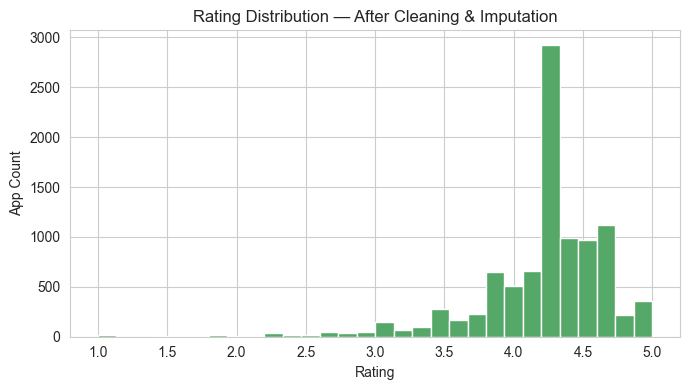

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
df['Rating'].hist(bins=30, ax=ax, color='#55A868', edgecolor='white')
ax.set_title('Rating Distribution — After Cleaning & Imputation')
ax.set_xlabel('Rating')
ax.set_ylabel('App Count')
plt.tight_layout()
plt.savefig('rating_hist_after.png')
plt.show()

In [9]:
def iqr_flags(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (series < lower) | (series > upper), lower, upper
rev_outlier, rev_lo, rev_hi = iqr_flags(df['Reviews'])
ins_outlier, ins_lo, ins_hi = iqr_flags(df['Installs'])
df['Reviews_Outlier'] = rev_outlier
df['Installs_Outlier'] = ins_outlier
print(f"Reviews outliers:  {rev_outlier.sum()} apps (bounds: {rev_lo:,.0f} to {rev_hi:,.0f})")
print(f"Installs outliers: {ins_outlier.sum()} apps (bounds: {ins_lo:,.0f} to {ins_hi:,.0f})")

Reviews outliers:  1659 apps (bounds: -44,118 to 73,596)
Installs outliers: 1981 apps (bounds: -1,497,500 to 2,498,500)


In [10]:
outlier_by_category = (
    df.groupby('Category')[['Reviews_Outlier', 'Installs_Outlier']]
    .sum()
    .sort_values('Reviews_Outlier', ascending=False)
)
outlier_by_category.head(10)

,Reviews_Outlier,Installs_Outlier
Category,,
GAME,368,381
FAMILY,259,303
TOOLS,135,174
PHOTOGRAPHY,101,124
COMMUNICATION,84,99
PRODUCTIVITY,77,91
SPORTS,66,74
SOCIAL,61,67
SHOPPING,53,72


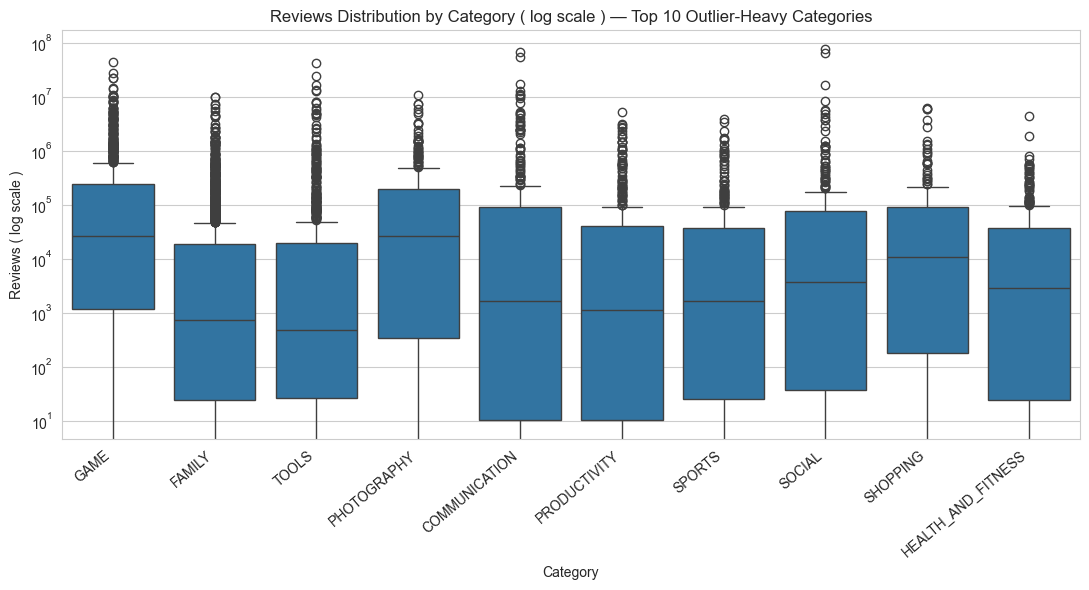

In [11]:
top_categories = outlier_by_category.head(10).index
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    data=df[df['Category'].isin(top_categories)],
    x='Category', y='Reviews', ax=ax, showfliers=True,
    order=top_categories
)
ax.set_yscale('log')
ax.set_title('Reviews Distribution by Category ( log scale ) — Top 10 Outlier-Heavy Categories')
ax.set_ylabel('Reviews ( log scale )')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('outlier_boxplot_reviews.png')
plt.show()

In [12]:
bench = df.groupby('Category').agg(
    Median_Rating=('Rating', 'median'),
    Median_Installs=('Installs', 'median'),
    App_Count=('App', 'count'),
    Free_Count=('Type', lambda s: (s == 'Free').sum()),
    Paid_Count=('Type', lambda s: (s == 'Paid').sum()),
).reset_index()
bench['Free_Pct'] = (bench['Free_Count'] / bench['App_Count'] * 100).round(1)
bench['Paid_Pct'] = (bench['Paid_Count'] / bench['App_Count'] * 100).round(1)
bench = bench.sort_values('Median_Installs', ascending=False).reset_index(drop=True)
bench

,Category,Median_Rating,Median_Installs,App_Count,Free_Count,Paid_Count,Free_Pct,Paid_Pct
0,EDUCATION,4.4,1000000.0,106,104,2,98.1,1.9
1,SHOPPING,4.3,1000000.0,202,200,2,99.0,1.0
2,ENTERTAINMENT,4.2,1000000.0,86,84,2,97.7,2.3
3,GAME,4.3,1000000.0,945,863,82,91.3,8.7
4,PHOTOGRAPHY,4.3,1000000.0,281,262,19,93.2,6.8
5,VIDEO_PLAYERS,4.2,1000000.0,164,160,4,97.6,2.4
6,WEATHER,4.3,1000000.0,79,71,8,89.9,10.1
7,HOUSE_AND_HOME,4.2,500000.0,73,73,0,100.0,0.0
8,FOOD_AND_DRINK,4.3,300000.0,112,110,2,98.2,1.8
9,ART_AND_DESIGN,4.4,100000.0,61,58,3,95.1,4.9


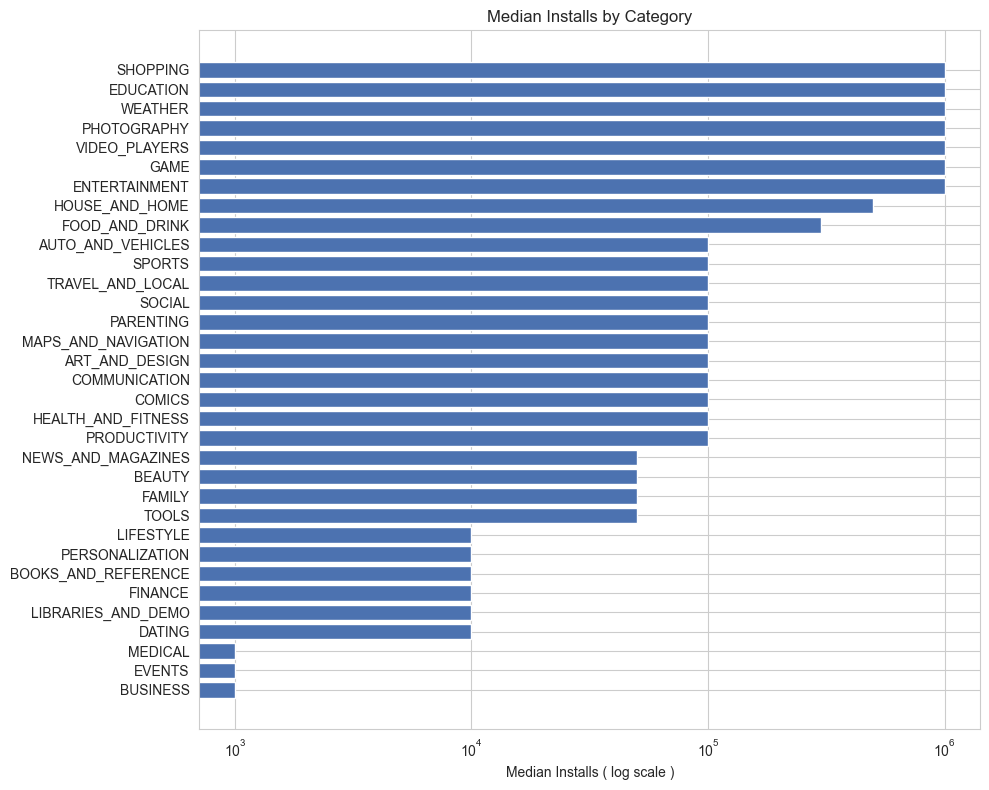

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))
bench_sorted = bench.sort_values('Median_Installs', ascending=True)
ax.barh(bench_sorted['Category'], bench_sorted['Median_Installs'], color='#4C72B0')
ax.set_xscale('log')
ax.set_xlabel('Median Installs ( log scale )')
ax.set_title('Median Installs by Category')
plt.tight_layout()
plt.savefig('median_installs_by_category.png')
plt.show()

In [15]:
free_vs_paid = df.groupby('Type')[['Rating', 'Installs', 'Reviews']].median()
free_vs_paid

,Rating,Installs,Reviews
Type,,,
Free,4.3,100000.0,1379.0
Paid,4.3,1000.0,88.5


C:\Users\Amin Rzazade\AppData\Local\Temp\ipykernel_14476\4017055762.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Type', y='Rating', ax=ax, palette=['#4C72B0', '#DD8452'])


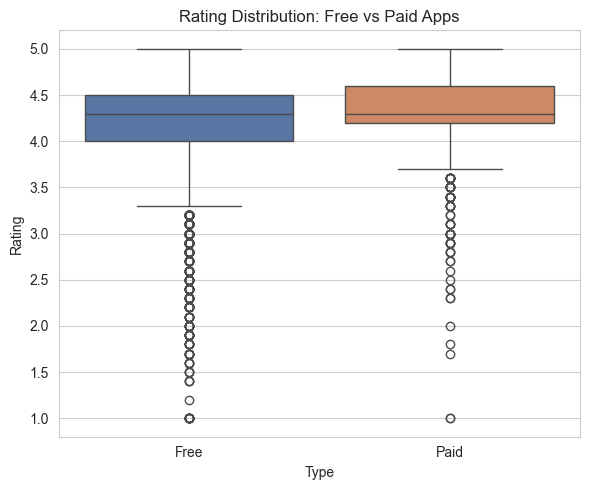

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df, x='Type', y='Rating', ax=ax, palette=['#4C72B0', '#DD8452'])
ax.set_title('Rating Distribution: Free vs Paid Apps')
plt.tight_layout()
plt.savefig('free_vs_paid_rating_boxplot.png')
plt.show()

In [17]:
bench['rating_rank'] = bench['Median_Rating'].rank(ascending=False)
bench['installs_rank'] = bench['Median_Installs'].rank(ascending=False)
bench['combined_rank'] = bench['rating_rank'] + bench['installs_rank']
top5 = bench.sort_values('combined_rank').head(5)
top5[['Category', 'Median_Rating', 'Median_Installs', 'App_Count', 'Free_Pct']]

,Category,Median_Rating,Median_Installs,App_Count,Free_Pct
0,EDUCATION,4.4,1000000.0,106,98.1
13,HEALTH_AND_FITNESS,4.5,100000.0,288,94.8
3,GAME,4.3,1000000.0,945,91.3
1,SHOPPING,4.3,1000000.0,202,99.0
6,WEATHER,4.3,1000000.0,79,89.9


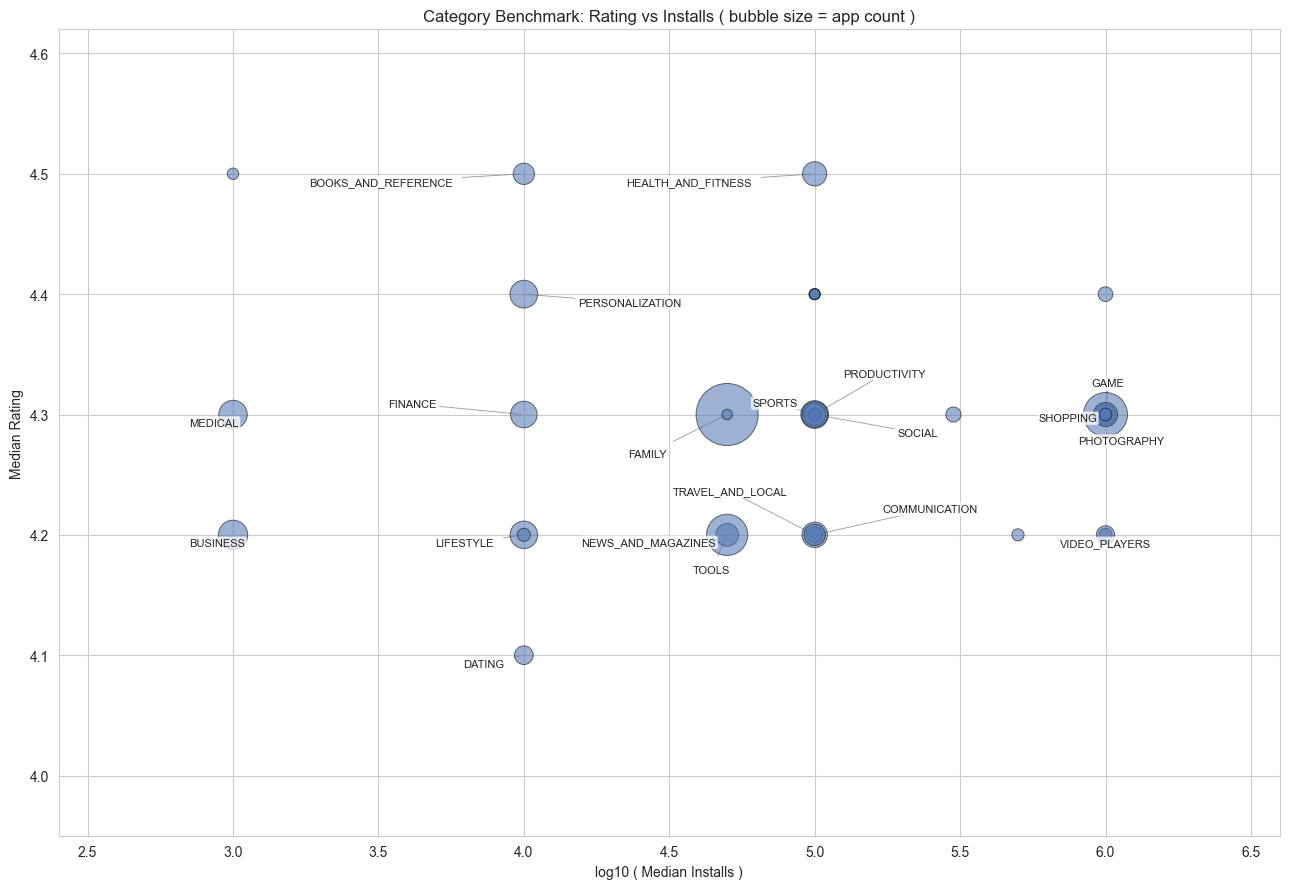

In [21]:
from adjustText import adjust_text
fig, ax = plt.subplots(figsize=(13, 9))
sizes = bench['App_Count'] / bench['App_Count'].max() * 2000
ax.scatter(
    np.log10(bench['Median_Installs']),
    bench['Median_Rating'],
    s=sizes, alpha=0.55, color='#4C72B0', edgecolor='black', linewidth=0.7, zorder=2
)
texts = []
labeled = bench[bench['App_Count'] > 150]
for _, row in labeled.iterrows():
    t = ax.text(
        np.log10(row['Median_Installs']), row['Median_Rating'], row['Category'],
        fontsize=8, ha='center', va='center', zorder=3,
        bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.75)
    )
    texts.append(t)
adjust_text(
    texts, ax=ax,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.6, alpha=0.8),
    expand=(2.2, 2.4),
    force_text=(1.0, 1.2),
    force_static=(0.6, 0.6),
    force_pull=(0.02, 0.02),
    max_move=(200, 200),
    time_lim=5,
)
xpad = 0.6
ax.set_xlim(np.log10(bench['Median_Installs']).min() - xpad, np.log10(bench['Median_Installs']).max() + xpad)
ax.set_ylim(bench['Median_Rating'].min() - 0.15, bench['Median_Rating'].max() + 0.12)
ax.set_xlabel('log10 ( Median Installs )')
ax.set_ylabel('Median Rating')
ax.set_title('Category Benchmark: Rating vs Installs ( bubble size = app count )')
plt.tight_layout()
plt.savefig('bubble_rating_vs_installs.png')
plt.show()

In [19]:
pivot = df.groupby(['Category', 'Type'])['Rating'].median().unstack()
pivot = pivot.dropna(subset=['Free', 'Paid'])
pivot['Rating_Diff_Paid_minus_Free'] = pivot['Paid'] - pivot['Free']
flagged = pivot[pivot['Rating_Diff_Paid_minus_Free'] > 0.15].sort_values(
    'Rating_Diff_Paid_minus_Free', ascending=False
)
flagged

Type,Free,Paid,Rating_Diff_Paid_minus_Free
Category,,,
NEWS_AND_MAGAZINES,4.2,4.8,0.6
EDUCATION,4.4,4.8,0.4
ENTERTAINMENT,4.2,4.6,0.4
ART_AND_DESIGN,4.4,4.7,0.3
SHOPPING,4.3,4.5,0.2
WEATHER,4.3,4.5,0.2


In [22]:
df.to_csv('googleplaystore_cleaned.csv', index=False)
print("Saved cleaned dataset:", df.shape)

Saved cleaned dataset: (9659, 15)
